In [ ]:
# For tips on running notebooks in Google Colab, see
# https://pytorch.org/tutorials/beginner/colab
%matplotlib inline

[Learn the Basics](intro.html) \|\|
[Quickstart](quickstart_tutorial.html) \|\|
[Tensors](tensorqs_tutorial.html) \|\| **Datasets & DataLoaders** \|\|
[Transforms](transforms_tutorial.html) \|\| [Build
Model](buildmodel_tutorial.html) \|\|
[Autograd](autogradqs_tutorial.html) \|\|
[Optimization](optimization_tutorial.html) \|\| [Save & Load
Model](saveloadrun_tutorial.html)

Datasets & DataLoaders
======================


Code for processing data samples can get messy and hard to maintain; we
ideally want our dataset code to be decoupled from our model training
code for better readability and modularity. PyTorch provides two data
primitives: `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`
that allow you to use pre-loaded datasets as well as your own data.
`Dataset` stores the samples and their corresponding labels, and
`DataLoader` wraps an iterable around the `Dataset` to enable easy
access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such
as FashionMNIST) that subclass `torch.utils.data.Dataset` and implement
functions specific to the particular data. They can be used to prototype
and benchmark your model. You can find them here: [Image
Datasets](https://pytorch.org/vision/stable/datasets.html), [Text
Datasets](https://pytorch.org/text/stable/datasets.html), and [Audio
Datasets](https://pytorch.org/audio/stable/datasets.html)


//自增笔记📒：
一般期待训练代码和数据集代码解耦

Loading a Dataset
=================

Here is an example of how to load the
[Fashion-MNIST](https://research.zalando.com/project/fashion_mnist/fashion_mnist/)
dataset from TorchVision. Fashion-MNIST is a dataset of Zalando's
article images consisting of 60,000 training examples and 10,000 test
examples. Each example comprises a 28×28 grayscale image and an
associated label from one of 10 classes.

We load the [FashionMNIST Dataset](https://pytorch.org/vision/stable/datasets.html#fashion-mnist) with the following parameters:

-   `root` is the path where the train/test data is stored,
-   `train` specifies training or test dataset,
-   `download=True` downloads the data from the internet if it\'s
        not available at `root`.
-   `transform` and `target_transform` specify the feature and label
        transformations


//自增笔记📒：
- root：训练/测试数据目录
- train：是训练还是测试模式
- download=True 如果root目录没有可用数据集，就从网上下载
- transform/target_transform：专门对输入特征/标签做变换，前者例如resize，归一化，转tensor；后者例如分类标签转one-hot，数值标签归一化

In [1]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt


training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()#把生成的数据转张量
)

Iterating and Visualizing the Dataset
=====================================

We can index `Datasets` manually like a list: `training_data[index]`. We
use `matplotlib` to visualize some samples in our training data.


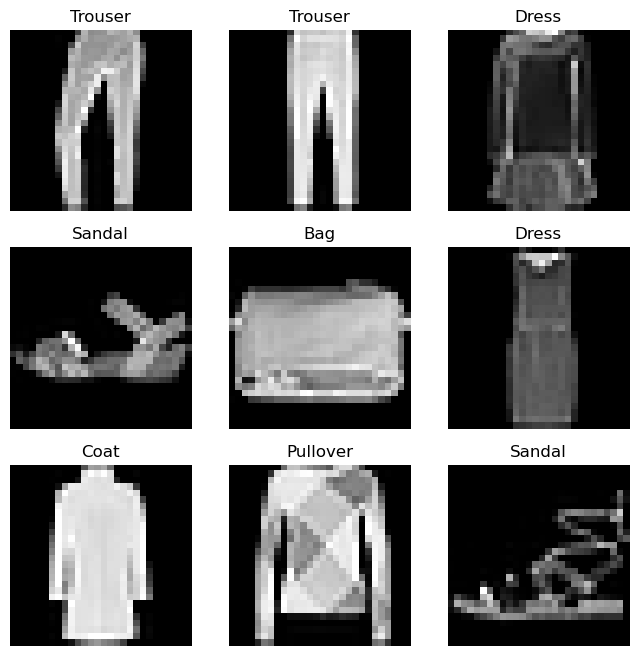

In [ ]:
labels_map = {#标签与数字index之间进行映射
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3#三行三列
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()#torch.randint(上限, size=(1,))在0到上限-1之间取一个随机数，即从训练数据中随机选，生成一维张量后转为普通数字
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)#给figure（画布）添加子图，把画布切割为网格，在指定位置放一个子图坐标系
    plt.title(labels_map[label])#title就是数字映射回标签
    plt.axis("off")#隐藏所有坐标轴，刻度线，刻度标签和边框
    plt.imshow(img.squeeze(), cmap="gray")#把数组里维度为1的无用通道维度删掉，让灰度图像正常显示
plt.show()

------------------------------------------------------------------------


Creating a Custom Dataset for your files
========================================

A custom Dataset class must implement three functions:
[\_\_init\_\_]{.title-ref}, [\_\_len\_\_]{.title-ref}, and
[\_\_getitem\_\_]{.title-ref}. 
Take a look at this implementation; the
FashionMNIST images are stored in a directory `img_dir`, and their
labels are stored separately in a CSV file `annotations_file`.

In the next sections, we\'ll break down what\'s happening in each of
these functions.


//自增笔记📒：
自定义数据集类必须实现三个方法：
__init__\__len__\__getitem__
图像和标签分别存储

In [3]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)#读csv文件取出标签
        self.img_dir = img_dir
        self.transform = transform#处理输入数据
        self.target_transform = target_transform#处理标签

    def __len__(self):
        return len(self.img_labels)#算出总共多少条数据

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])#对存了图片名的表格取第idx行，第0列的值，得到完整的一张图片的路径
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]#表格第二列是label
        if self.transform:#如果有对图片和标签设置了预处理操作，就去做相应处理
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

`__init__`
==========

The \_\_[init](#init__) function is run once when instantiating the
Dataset object. We initialize the directory containing the images, the
annotations file, and both transforms (covered in more detail in the
next section).

The labels.csv file looks like: :

    tshirt1.jpg, 0
    tshirt2.jpg, 0
    ......
    ankleboot999.jpg, 9//左边图片文件名，右边对应数字标签


In [4]:
def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):#init只运行一次，初始化三种东西：存放图片的路径，annotation标注文件，处理数据和标签的变换方法
    self.img_labels = pd.read_csv(annotations_file)
    self.img_dir = img_dir
    self.transform = transform
    self.target_transform = target_transform

`__len__`
=========

The \_\_[len](#len__) function returns the number of samples in our
dataset.

Example:


In [5]:
def __len__(self):#返回数据集中的sample数据量
    return len(self.img_labels)

`__getitem__`
=============

The \_\_[getitem](#getitem__) function loads and returns a sample from
the dataset at the given index `idx`. Based on the index, it identifies
the image\'s location on disk, converts that to a tensor using
`read_image`, retrieves the corresponding label from the csv data in
`self.img_labels`, calls the transform functions on them (if
applicable), and returns the tensor image and corresponding label in a
tuple.


//自增笔记📒：

__getitem__是python的魔法方法，让自定义类的对象支持[idx]取值获取单条样本的操作
写dataset[idx]时回自动调用这个类里面的__getitem__（idx）方法，任务即根据传入的索引idx返回对应的数据样本。


In [ ]:
def __getitem__(self, idx):
    img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])#iloc = 按位置索引
    image = read_image(img_path)
    label = self.img_labels.iloc[idx, 1]
    if self.transform:
        image = self.transform(image)
    if self.target_transform:
        label = self.target_transform(label)
    return image, label

------------------------------------------------------------------------


Preparing your data for training with DataLoaders
=================================================

The `Dataset` retrieves our dataset\'s features and labels one sample at
a time. While training a model, we typically want to pass samples in
\"minibatches\", reshuffle the data at every epoch to reduce model
overfitting, and use Python\'s `multiprocessing` to speed up data
retrieval.

`DataLoader` is an iterable that abstracts this complexity for us in an
easy API.


//自增笔记📒：

- dataset一次只取一个样本，训练时需要：批处理，每个epoch打乱防过拟合，用多进程并行读取数据提速；
- dataloader的价值：可迭代对象iteration，把上述复杂操作封装为一个API，直接调用即可拿到训练所需批量数据

In [7]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Iterate through the DataLoader
==============================

We have loaded that dataset into the `DataLoader` and can iterate
through the dataset as needed. Each iteration below returns a batch of
`train_features` and `train_labels` (containing `batch_size=64` features
and labels respectively). Because we specified `shuffle=True`, after we
iterate over all batches the data is shuffled (for finer-grained control
over the data loading order, take a look at
[Samplers](https://pytorch.org/docs/stable/data.html#data-loading-order-and-sampler)).


Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


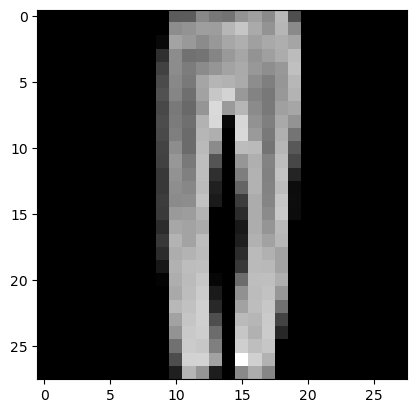

Label: 1


In [ ]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")#【batch-size,tunnel,h,w】
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()#去除维度为1的
label = train_labels[0]
plt.imshow(img, cmap="gray")#colormap（颜色映射），决定数值对应什么颜色，gray-把图像/数据用灰度色阶显示
plt.show()
print(f"Label: {label}")

------------------------------------------------------------------------


Further Reading
===============

-   [torch.utils.data API](https://pytorch.org/docs/stable/data.html)
